In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import kagglehub
from kagglehub import KaggleDatasetAdapter


file_path = "student_performance.csv"


df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "nabeelqureshitiii/student-performance-dataset",
  file_path,
)

df.head(3)

C:\Users\meral\AppData\Local\Temp\ipykernel_13000\3302804378.py:19: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A


In [35]:
df.drop_duplicates(inplace=True)

df.drop(['student_id'], axis=1, inplace=True)

df.fillna(df.mean(numeric_only=True), inplace=True)


le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

    
df = df[(np.abs(df.select_dtypes(include=[np.number]) - df.mean()) <= (3 * df.std())).all(axis=1)]

In [36]:
X = df.drop('total_score', axis=1) 
y = df['total_score']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred) 
rmse = np.sqrt(mse) 
r2 = r2_score(y_test, y_pred)


print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R2 Score: {r2}")

Root Mean Squared Error (RMSE): 4.071438383574068
R2 Score: 0.926091476105429


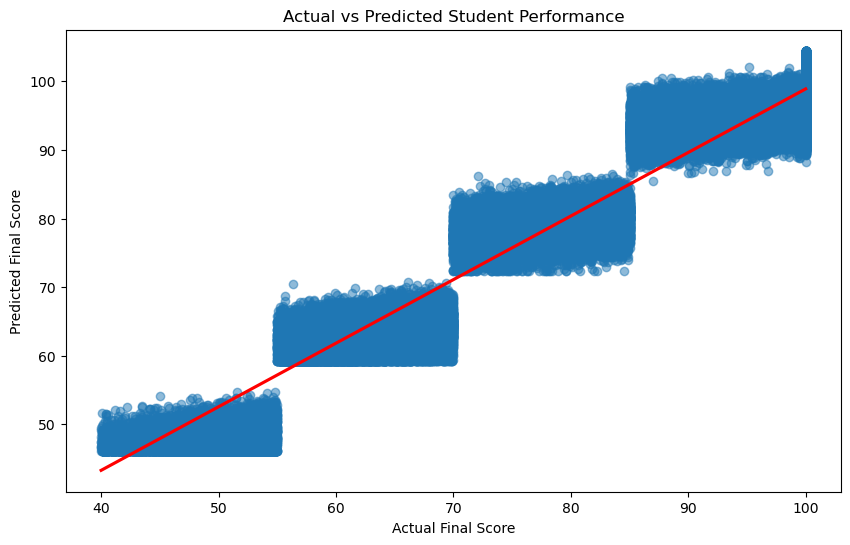

In [39]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')
plt.title('Actual vs Predicted Student Performance')
plt.show()

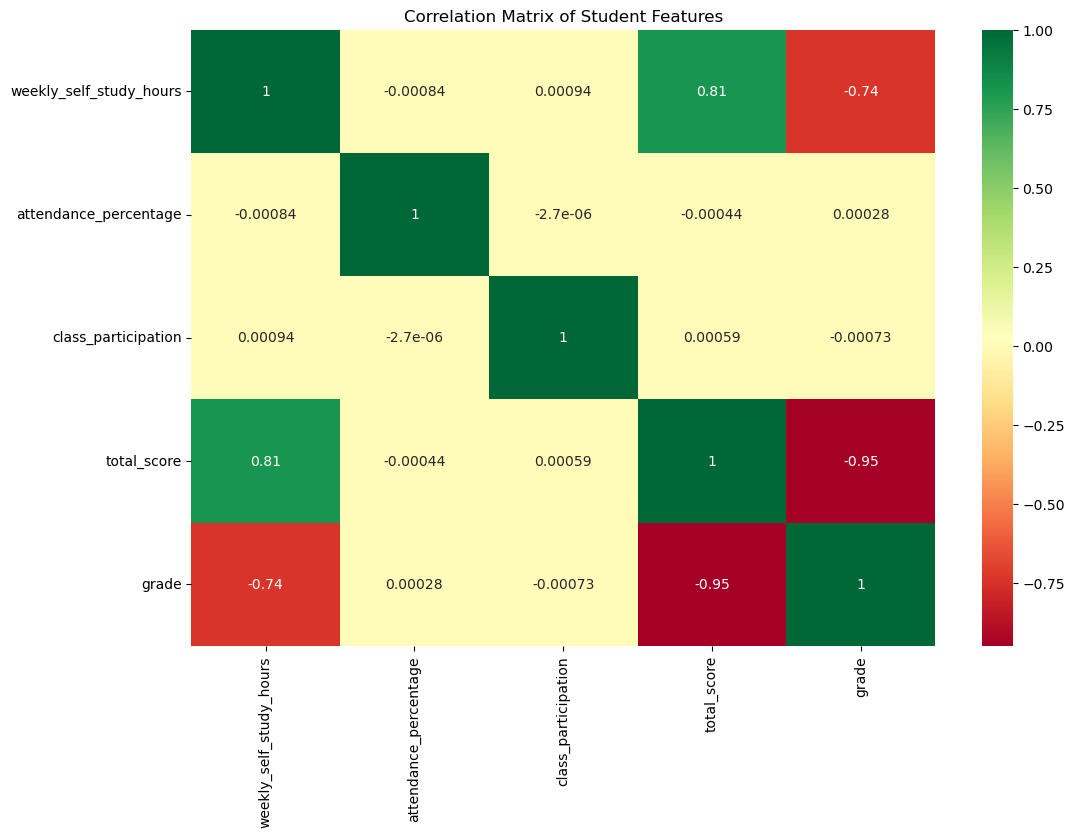

In [40]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn')
plt.title('Correlation Matrix of Student Features')
plt.show()